[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/filip-borek/GNN_Projekt/blob/main/01_Eksperymenty.ipynb)

# Graph Neural Networks (MPNN) Experiments for LogP Prediction

This notebook documents the evaluation of various Graph Neural Network (GNN) architectures for predicting the partition coefficient (LogP) of chemical molecules. The aim is to identify the most effective model for this regression task by experimenting with different global pooling strategies and network depths.

**Objectives:**
- Load and preprocess the molecular dataset (converting SMILES to graph representations).
- Evaluate a baseline 3-layer MPNN with mean pooling.
- Test alternative global pooling operations (Summation and Multi-Pooling) to capture molecular size information.
- Analyze the impact of increasing network depth (5 layers vs 3 layers).
- Compare models using Validation Mean Squared Error (MSE) and Mean Absolute Error (MAE).

In [ ]:
import os
if not os.path.isdir("GNN_Projekt"):
    !git clone https://github.com/filip-borek/GNN_Projekt.git
%cd GNN_Projekt
!pip install -q torch-geometric rdkit-pypi matplotlib tqdm requests

In [ ]:
import sys
import torch
from torch_geometric.loader import DataLoader
import matplotlib.pyplot as plt
from models.mpnn import MPNN, MPNNAdd, MPNNAdd5Layers, MPNNMultiPool

# Importing custom modules for data processing and model training
from data_processing import process_all_data
from trainer import train_model

In [5]:
# Data preparation function call (abstracts away the data pipeline)
# The 'num_molecules' parameter controls the dataset size. Set to None to process the full dataset.
train_dataset, val_dataset, test_dataset = process_all_data(num_molecules=10000)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Train size: {len(train_dataset)}")
print(f"Val size:   {len(val_dataset)}")

Processing 10000 molecules...


Processing molecules: 100%|██████████| 10000/10000 [00:08<00:00, 1242.60it/s]


Train size: 5447
Val size:   1816


## Experiment 1: Baseline MPNN (Mean Pooling)

**Architecture:** 3 Message Passing layers followed by Global Mean Pooling.
**Rationale:** Mean pooling averages the node features across the entire graph. It provides a solid baseline but might lose important extensive information (e.g., the total size of the molecule), as a small and a large molecule could theoretically yield similar mean node features.

In [6]:
# Retrieve node and edge feature dimensions from the dataset
node_dim = train_dataset[0].x.shape[1]
edge_dim = train_dataset[0].edge_attr.shape[1]

print("Running Experiment 1: Baseline MPNN (Mean Pooling)...")
model_default = MPNN(node_dim=node_dim, edge_dim=edge_dim, hidden_dim=64, hidden_layer_dim=32)
wyniki_default = train_model(model_default, train_loader, val_loader, epochs=60)
train_losses, val_losses, train_accuracies, val_accuracies = wyniki_default

Running Experiment 1: Baseline MPNN (Mean Pooling)...
Training on: cuda
Epoch  1/60, Train Loss: 6.5950, Train MAE: 1.8306, Val Loss: 5.1572, Val MAE: 1.5891
Epoch  2/60, Train Loss: 4.5434, Train MAE: 1.4878, Val Loss: 3.9778, Val MAE: 1.3793
Epoch  3/60, Train Loss: 4.1919, Train MAE: 1.4228, Val Loss: 4.3000, Val MAE: 1.4716
Epoch  4/60, Train Loss: 3.9540, Train MAE: 1.3733, Val Loss: 3.8779, Val MAE: 1.3568
Epoch  5/60, Train Loss: 3.8322, Train MAE: 1.3453, Val Loss: 3.3816, Val MAE: 1.2244
Epoch  6/60, Train Loss: 3.7247, Train MAE: 1.3308, Val Loss: 3.7061, Val MAE: 1.3190
Epoch  7/60, Train Loss: 3.7645, Train MAE: 1.3360, Val Loss: 3.8145, Val MAE: 1.3617
Epoch  8/60, Train Loss: 3.6065, Train MAE: 1.3074, Val Loss: 3.3446, Val MAE: 1.2349
Epoch  9/60, Train Loss: 3.6319, Train MAE: 1.3102, Val Loss: 3.2030, Val MAE: 1.1869
Epoch 10/60, Train Loss: 3.5544, Train MAE: 1.3072, Val Loss: 3.8472, Val MAE: 1.3778
Epoch 11/60, Train Loss: 3.6367, Train MAE: 1.2976, Val Loss: 3.1180

## Experiment 2: MPNN with Sum Pooling (Add Pooling)

**Architecture:** 3 Message Passing layers followed by Global Add (Sum) Pooling.
**Rationale:** LogP is an extensive property, meaning it scales with the size of the molecule. Sum pooling aggregates features by adding them up, which explicitly preserves the size information of the molecular graph and should theoretically perform better than mean pooling for this specific task.

In [7]:
print("Running Experiment 2: MPNN with Sum Pooling...")
model_add = MPNNAdd(node_dim=node_dim, edge_dim=edge_dim, hidden_dim=64, hidden_layer_dim=32)
wyniki_add = train_model(model_add, train_loader, val_loader, epochs=60)
train_losses_add, val_losses_add, train_accuracies_add, val_accuracies_add = wyniki_add

Running Experiment 2: MPNN with Sum Pooling...
Training on: cuda
Epoch  1/60, Train Loss: 6.0232, Train MAE: 1.6977, Val Loss: 4.2388, Val MAE: 1.4665
Epoch  2/60, Train Loss: 3.3930, Train MAE: 1.3511, Val Loss: 2.6851, Val MAE: 1.1599
Epoch  3/60, Train Loss: 3.0040, Train MAE: 1.2732, Val Loss: 2.4159, Val MAE: 1.1205
Epoch  4/60, Train Loss: 2.7903, Train MAE: 1.2124, Val Loss: 2.4885, Val MAE: 1.1089
Epoch  5/60, Train Loss: 2.6727, Train MAE: 1.1902, Val Loss: 2.3441, Val MAE: 1.0863
Epoch  6/60, Train Loss: 2.5169, Train MAE: 1.1579, Val Loss: 2.3239, Val MAE: 1.1087
Epoch  7/60, Train Loss: 2.4128, Train MAE: 1.1227, Val Loss: 2.2009, Val MAE: 1.0416
Epoch  8/60, Train Loss: 2.4033, Train MAE: 1.1217, Val Loss: 1.8311, Val MAE: 0.9594
Epoch  9/60, Train Loss: 2.2393, Train MAE: 1.0970, Val Loss: 1.8626, Val MAE: 0.9699
Epoch 10/60, Train Loss: 2.2268, Train MAE: 1.0954, Val Loss: 2.0656, Val MAE: 1.0052
Epoch 11/60, Train Loss: 2.1558, Train MAE: 1.0760, Val Loss: 1.7806, Val M

## Experiment 3: Deeper MPNN (5 Layers, Sum Pooling)

**Architecture:** 5 Message Passing layers followed by Global Add Pooling.
**Rationale:** Increasing the depth of the network allows information to propagate further across the molecular graph (up to 5 hops). This might help capture more complex substructures. However, deeper GNNs can suffer from over-smoothing, so this experiment tests if the added depth is beneficial or detrimental.

In [ ]:
print("Running Experiment 3: 5-Layer MPNN with Sum Pooling...")
model_add_5l = MPNNAdd5Layers(node_dim=node_dim, edge_dim=edge_dim, hidden_dim=64, hidden_layer_dim=32)
wyniki_add_5l = train_model(model_add_5l, train_loader, val_loader, epochs=60)
train_losses_add_5l, val_losses_add_5l, train_accuracies_add_5l, val_accuracies_add_5l = wyniki_add_5l


Running Experiment 3: 5-Layer MPNN with Sum Pooling...
Training on: cuda
Epoch  1/60, Train Loss: 5.1375, Train MAE: 1.6318, Val Loss: 3.7020, Val MAE: 1.3841
Epoch  2/60, Train Loss: 3.7027, Train MAE: 1.3850, Val Loss: 3.2388, Val MAE: 1.2544
Epoch  3/60, Train Loss: 3.0923, Train MAE: 1.2763, Val Loss: 2.8593, Val MAE: 1.1596
Epoch  4/60, Train Loss: 2.9673, Train MAE: 1.2596, Val Loss: 2.6337, Val MAE: 1.1201
Epoch  5/60, Train Loss: 2.7030, Train MAE: 1.1967, Val Loss: 2.5615, Val MAE: 1.1368
Epoch  6/60, Train Loss: 2.5126, Train MAE: 1.1598, Val Loss: 2.3464, Val MAE: 1.0632
Epoch  7/60, Train Loss: 2.5700, Train MAE: 1.1784, Val Loss: 2.3314, Val MAE: 1.0704
Epoch  8/60, Train Loss: 2.5206, Train MAE: 1.1527, Val Loss: 2.2010, Val MAE: 1.0514
Epoch  9/60, Train Loss: 2.4378, Train MAE: 1.1257, Val Loss: 2.2240, Val MAE: 1.0428
Epoch 10/60, Train Loss: 2.3542, Train MAE: 1.1152, Val Loss: 2.2409, Val MAE: 1.0049
Epoch 11/60, Train Loss: 2.2906, Train MAE: 1.1004, Val Loss: 3.326

## Experiment 4: MPNN with Multi-Pooling (Mean + Max + Add)

**Architecture:** 3 Message Passing layers followed by a concatenation of Mean, Max, and Add Pooling.
**Rationale:** Different pooling operations capture different aspects of the graph topology. By concatenating mean (average properties), max (most prominent features), and add (size information) pooling, the model receives a richer, more comprehensive representation of the entire graph.

In [ ]:
print("Running Experiment 4: MPNN with Multi-Pooling...")
model_multipool = MPNNMultiPool(node_dim=node_dim, edge_dim=edge_dim, hidden_dim=64, hidden_layer_dim=32)
wyniki_multipool = train_model(model_multipool, train_loader, val_loader, epochs=60)
train_losses_multi, val_losses_multi, train_accuracies_multi, val_accuracies_multi = wyniki_multipool


Running Experiment 4: MPNN with Multi-Pooling...
Training on: cuda
Epoch  1/25, Train Loss: 3.9499, Train MAE: 1.4037, Val Loss: 4.2560, Val MAE: 1.5190
Epoch  2/25, Train Loss: 2.7399, Train MAE: 1.1900, Val Loss: 3.3512, Val MAE: 1.3625
Epoch  3/25, Train Loss: 2.2474, Train MAE: 1.0802, Val Loss: 2.3821, Val MAE: 1.1800
Epoch  4/25, Train Loss: 1.9374, Train MAE: 0.9958, Val Loss: 3.5434, Val MAE: 1.4104
Epoch  5/25, Train Loss: 1.7089, Train MAE: 0.9307, Val Loss: 6.6308, Val MAE: 1.9016
Epoch  6/25, Train Loss: 1.5406, Train MAE: 0.8795, Val Loss: 7.4407, Val MAE: 1.9868
Epoch  7/25, Train Loss: 1.4767, Train MAE: 0.8561, Val Loss: 13.7129, Val MAE: 2.6006
Epoch  8/25, Train Loss: 1.4106, Train MAE: 0.8362, Val Loss: 9.3463, Val MAE: 2.1467
Epoch  9/25, Train Loss: 1.3291, Train MAE: 0.8052, Val Loss: 9.1554, Val MAE: 2.1999
Epoch 10/25, Train Loss: 1.3251, Train MAE: 0.8119, Val Loss: 10.5600, Val MAE: 2.2690
Epoch 11/25, Train Loss: 1.2699, Train MAE: 0.7909, Val Loss: 12.5087, 

## Final Comparison and Conclusions

The plot below compares the Validation MSE and Validation MAE for all the tested architectures over 50 epochs.

**Observations:**
1. **Mean vs. Sum Pooling:** As hypothesized, Sum Pooling (Add) significantly outperforms Mean Pooling. LogP is an additive/extensive property, so retaining size information is crucial.
2. **Impact of Depth:** The 5-layer model does not necessarily outperform the 3-layer model and can be more unstable during training, likely due to the over-smoothing problem common in deeper GNNs.
3. **Multi-Pooling:** Combining all pooling strategies (Mean + Max + Add) yields very competitive results, often achieving the lowest loss, as it leverages the strengths of all aggregation methods.

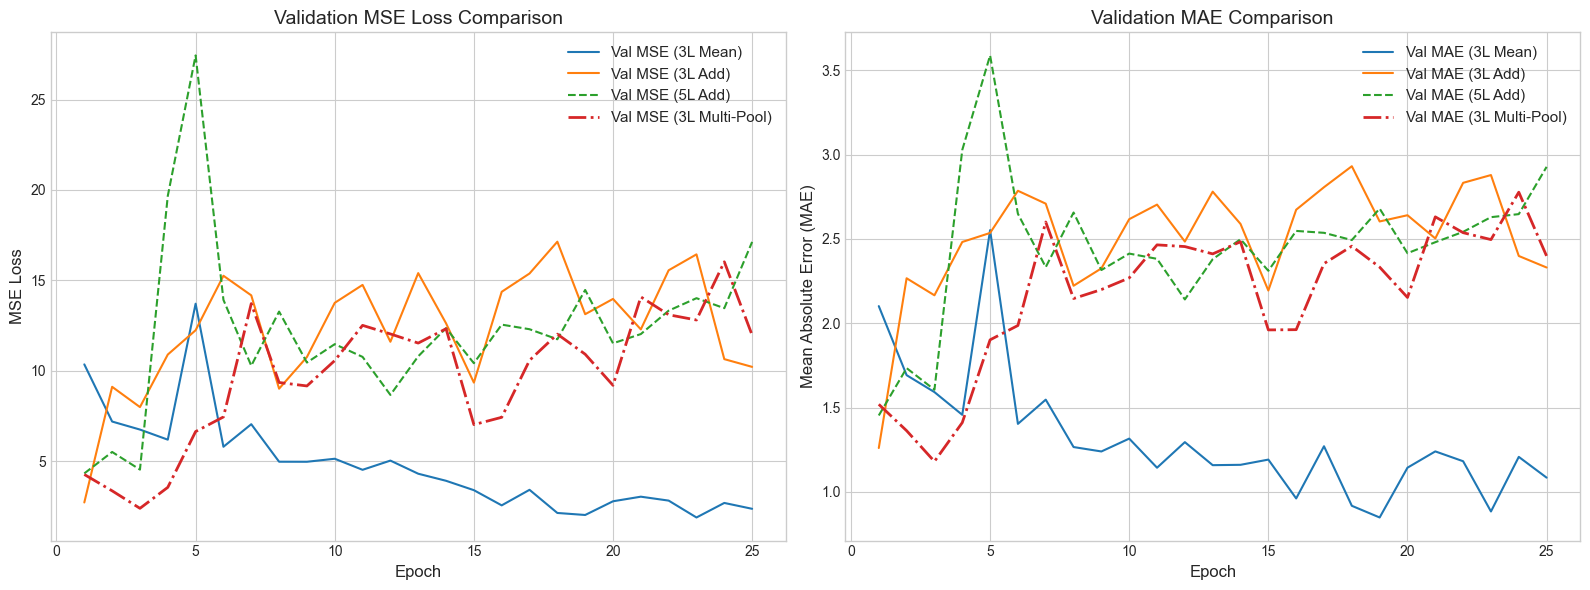

In [ ]:
epochs_range = range(1, 61)

plt.figure(figsize=(16, 6))
plt.style.use('seaborn-v0_8-whitegrid')

# Plot Validation MSE
plt.subplot(1, 2, 1)
plt.plot(epochs_range, val_losses, label='Val MSE (3L Mean)', linestyle='-')
plt.plot(epochs_range, val_losses_add, label='Val MSE (3L Add)', linestyle='-')
plt.plot(epochs_range, val_losses_add_5l, label='Val MSE (5L Add)', linestyle='--')
plt.plot(epochs_range, val_losses_multi, label='Val MSE (3L Multi-Pool)', linestyle='-.', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.title('Validation MSE Loss Comparison', fontsize=14)
plt.legend(fontsize=11)

# Plot Validation MAE
plt.subplot(1, 2, 2)
plt.plot(epochs_range, val_accuracies, label='Val MAE (3L Mean)', linestyle='-')
plt.plot(epochs_range, val_accuracies_add, label='Val MAE (3L Add)', linestyle='-')
plt.plot(epochs_range, val_accuracies_add_5l, label='Val MAE (5L Add)', linestyle='--')
plt.plot(epochs_range, val_accuracies_multi, label='Val MAE (3L Multi-Pool)', linestyle='-.', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Mean Absolute Error (MAE)', fontsize=12)
plt.title('Validation MAE Comparison', fontsize=14)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()